<a href="https://colab.research.google.com/github/Daniel9215/MCD/blob/main/An%C3%A1lisis_SARLAFT_Segmentacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SEGMENTACIÓN SARLAFT JULIO 2026

AREA DE PLANEACIÓN Y RIESGOS

Daniel Alejandro Rengifo Aguirre

1. Importación de Librerias

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression #modelamiento
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_auc_score,roc_curve, f1_score

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

In [12]:
from google.colab import drive

# Montar Google Drive
drive.mount('/content/drive')

# Ruta del archivo
ruta = "/content/drive/MyDrive/Segmentacion_Sarlaft.csv"

# Cargar el archivo
df = pd.read_csv(ruta, sep=";", encoding="latin-1")

# Ver las primeras filas
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Y_DEPEN,FECHA_TRANSACCION,TIPO_TRANSACCION,VALOR_SALIDA,VALOR_INGRESO,VALOR_EFECTIVO,NIT,CODIGO_PRODUCTO,HOMO_PRODUCTO,NUMERO_PRODUCTO,...,NOMBRE_DEL_CARGO_QUE_OSTENTE,AÑO.1,VINCULOS_CON_PPE,CARGO.1,NOMBRE_TERCERO,PARENTESCO,RECONOCEN_PERSONA_PUBLICA,VINCULOS_CON_UNA_PUBLICA,NOMBRE_TERCERO.1,PARENTESCO.1
0,0,15/12/2025,S,-,-,0,15441694,2,AHORROS,01-3010009965,...,SIN DATO,0,N,SIN DATO,SIN DATO,SIN DATO,N,N,SIN DATO,SIN DATO
1,0,15/12/2025,S,-,-,0,15441694,2,AHORROS,01-3010009965,...,SIN DATO,0,N,SIN DATO,SIN DATO,SIN DATO,N,N,SIN DATO,SIN DATO
2,0,4/12/2025,S,-,-,0,1113636116,2,AHORROS,01-1010142185,...,SIN DATO,0,N,SIN DATO,SIN DATO,SIN DATO,N,N,SIN DATO,SIN DATO
3,0,9/12/2025,S,-,-,0,94424415,2,AHORROS,01-2010168800,...,SIN DATO,0,N,SIN DATO,SIN DATO,SIN DATO,N,N,SIN DATO,SIN DATO
4,0,26/12/2025,I,-,-,0,31321196,2,AHORROS,01-1010021067,...,SIN DATO,0,N,SIN DATO,SIN DATO,SIN DATO,N,N,SIN DATO,SIN DATO


In [13]:
df.shape

(14465, 94)

In [15]:
df.describe()

,Y_DEPEN,VALOR_EFECTIVO,NIT,CODIGO_PRODUCTO,CODIGO_CANAL,ANTIGUEDAD,F_RETIRO,K_IDTERC,K_CIUDAD_NAC,EDAD,...,VALOR_SALDO_ACTIVOS,TOTAL_CUOTA_SERVSEG,SALDO_CREDITOS,CUOTA_CREDITOS,TOTAL_CDT,AHORRO_NAVIDENO,AHORRO_PROGRAMADO,AHORRO_VISTA,SALDO_APORTES,CUOTA_APORTES
count,14465.000000,1.446500e+04,1.446500e+04,14465.000000,14465.000000,14465.000000,14465.000000,14465.000000,14465.000000,14465.000000,...,1.446500e+04,1.446500e+04,1.446500e+04,1.446500e+04,1.446500e+04,1.446500e+04,1.446500e+04,1.446500e+04,1.446500e+04,14465.000000
mean,0.085033,4.039678e+05,2.649805e+08,3.007881,2.239060,120.383823,1367.371794,44069.574974,48100.508469,53.415555,...,1.268241e+07,1.130813e+06,1.876192e+07,6.522010e+05,3.715899e+06,6.847869e+04,2.542793e+04,3.514698e+04,1.468492e+07,70983.912133
std,0.278940,2.295239e+06,4.288133e+08,1.300504,0.982329,80.753218,7776.841880,23616.021347,31178.586653,14.686325,...,6.355919e+07,2.619500e+06,3.409437e+07,8.327890e+05,2.578801e+07,1.616962e+05,2.143288e+05,2.086831e+05,1.142406e+07,55167.263268
min,0.000000,0.000000e+00,1.183090e+05,1.000000,1.000000,4.000000,0.000000,20006.000000,5001.000000,22.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,0.000000,1.847600e+04,2.930643e+07,2.000000,1.000000,64.000000,0.000000,23286.000000,11001.000000,42.000000,...,0.000000e+00,1.000000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.529974e+06,28470.000000
50%,0.000000,6.832800e+04,5.173184e+07,3.000000,3.000000,98.000000,0.000000,27146.000000,73408.000000,52.000000,...,0.000000e+00,2.595270e+05,5.975833e+06,3.712970e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.229024e+07,49823.000000
75%,0.000000,2.660000e+05,9.440449e+07,4.000000,3.000000,172.000000,0.000000,67051.000000,76001.000000,64.000000,...,0.000000e+00,1.519836e+06,2.227091e+07,9.473930e+05,0.000000e+00,8.000000e+04,0.000000e+00,1.500000e+04,2.116064e+07,108115.000000
max,1.000000,1.950000e+08,1.235253e+09,7.000000,5.000000,422.000000,46125.000000,86770.000000,99999.000000,94.000000,...,1.550000e+09,9.427520e+07,3.461710e+08,6.685604e+06,7.242844e+08,1.750905e+06,4.000000e+06,8.000000e+06,7.660814e+07,476000.000000


In [16]:
#Paleta de colores.

sns.set_style("dark")
sns.color_palette("Paired")

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

In [17]:
# Contar los valores de la columna
scoring_counts = df['Y_DEPEN'].value_counts()

# Convertir a DataFrame para mejor visualización
tabla_resumen = pd.DataFrame({
    'Clasificación': scoring_counts.index,
    'Cantidad': scoring_counts.values
})

print(tabla_resumen)


   Clasificación  Cantidad
0              0     13235
1              1      1230


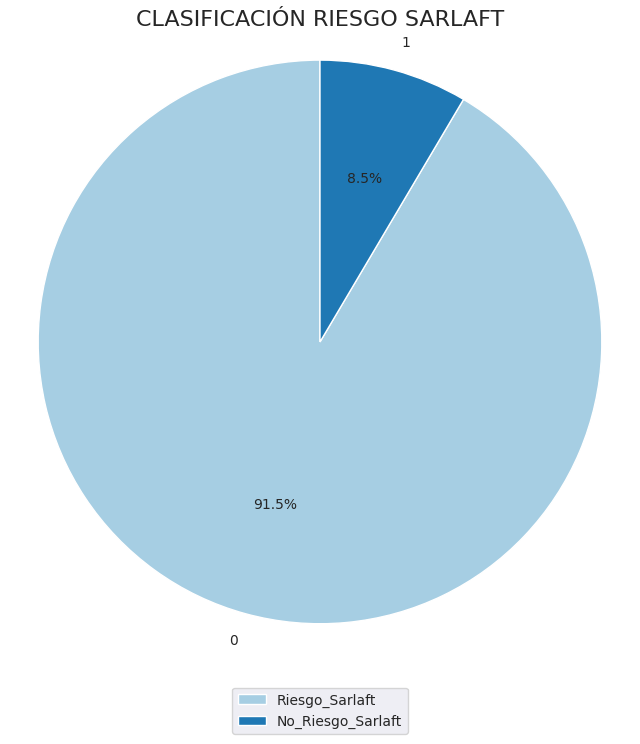

In [20]:
scoring_counts = df['Y_DEPEN'].value_counts()

# Configuración de estilo y colores
sns.set_style("dark")
colors = sns.color_palette("Paired")

# Gráfica de torta
plt.figure(figsize=(8, 8))
plt.pie(scoring_counts, labels=scoring_counts.index, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title("CLASIFICACIÓN RIESGO SARLAFT", fontsize=16)
plt.axis('equal')  # Asegurar que el gráfico sea circular

plt.legend(
    labels=['Riesgo_Sarlaft', 'No_Riesgo_Sarlaft'],
    loc='upper center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=1,
    fontsize=10
)

# Mostrar la gráfica
plt.show()

Se considera que un asociado presenta **riesgo SARLAFT** cuando cumple al menos una de las siguientes condiciones de alerta: registra alguna señal de riesgo previamente identificada en variables de vinculación, conocimiento del cliente o monitoreo (marcadas como "Y"); realiza operaciones con montos iguales o superiores a **$1.000.000**; desarrolla actividades económicas catalogadas como de mayor exposición al riesgo, tales como **trabajador independiente**, **persona no activa laboralmente** o actividades CIIU específicas (**6920 - Actividades jurídicas y de contabilidad**, **0124 - Cultivo de frutas tropicales y subtropicales**, **3211 - Fabricación de joyas y artículos conexos**, **6810 - Actividades inmobiliarias realizadas con bienes propios o arrendados** y **9200 - Actividades de juegos de azar y apuestas**); efectúa transacciones mediante la modalidad de **pagos por caja**; o se encuentra ubicado en municipios considerados de mayor exposición al riesgo para efectos del modelo, como **Cúcuta**, **Cartagena**, **Barranquilla** y **Santander de Quilichao**. Si se cumple cualquiera de estos criterios, el asociado es clasificado con riesgo SARLAFT; en caso contrario, se considera que no presenta las condiciones definidas por el modelo para dicha clasificación.
